<a href="https://colab.research.google.com/github/messias-antonio-analytics/Messias-Data-Analysis-Portfolio/blob/main/messias_nutri_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UNICEF DATA ANALYSIS DASHBOARD

[ANALYSIS 01] COMPARAÇÃO SAM vs MAM


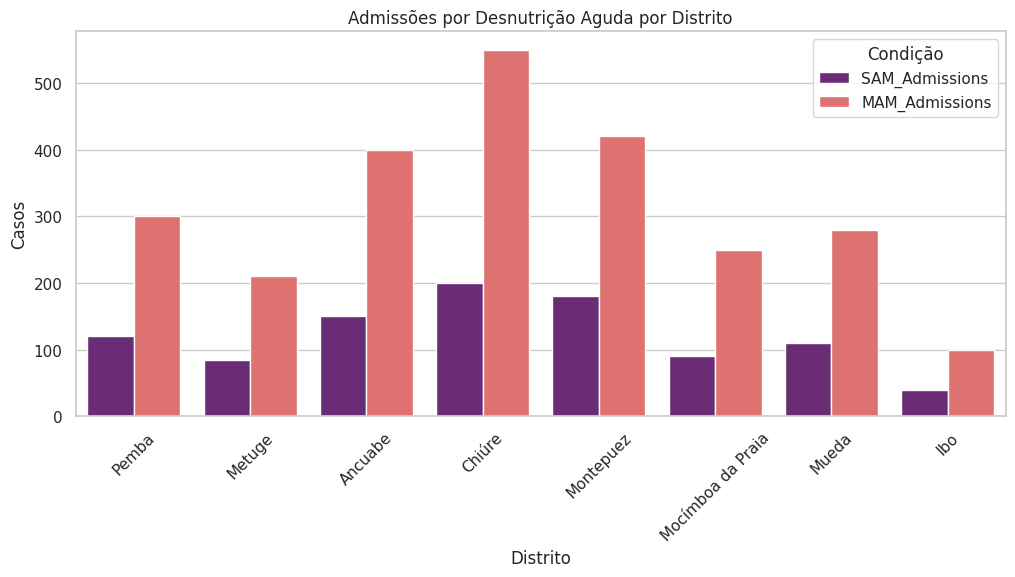

📍 TOMADA DE DECISÃO: Chiúre exige maior atenção clínica hoje.

[ANALYSIS 02] ESTOQUE DISPONÍVEL (PLUMPY'NUT)


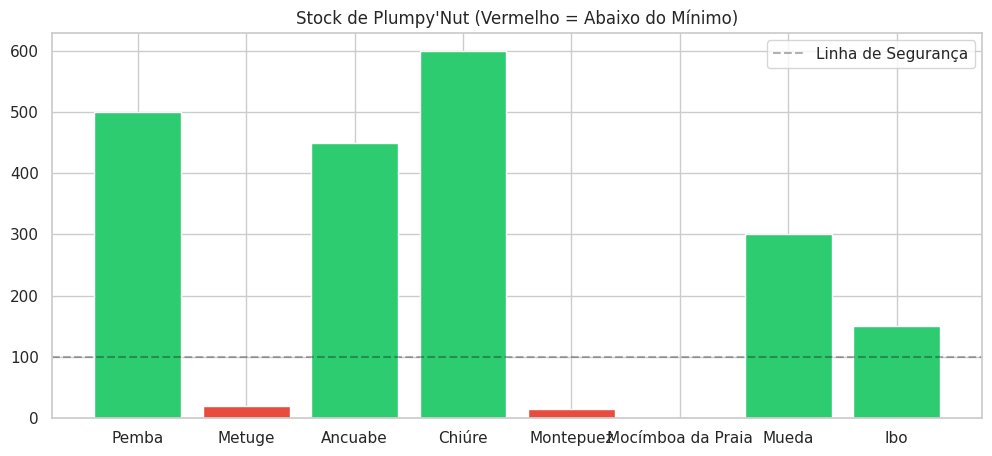

📍 TOMADA DE DECISÃO: Urgência no reabastecimento de: Metuge, Montepuez, Mocímboa da Praia

[ANALYSIS 03] MAPA DE PRIORIDADES GEOGRÁFICAS



RESUMO PARA O RELATÓRIO MENSAL (Actionable Insights):
            Distrito  SAM_Admissions Stock_Status      Nivel_Prioridade
4          Montepuez             180      Crítico  1. Emergência Máxima
1             Metuge              85      Crítico  2. Atenção Logística
2            Ancuabe             150   Suficiente  2. Atenção Logística
5  Mocímboa da Praia              90      Crítico  2. Atenção Logística
7                Ibo              40   Suficiente  2. Atenção Logística
0              Pemba             120   Suficiente            3. Estável
3             Chiúre             200   Suficiente            3. Estável
6              Mueda             110   Suficiente            3. Estável


In [ ]:
# =================================================================
# PROJECT: HEALTH & NUTRITION INTEGRATED DASHBOARD
# ORGANIZATION: PROTOTYPE FOR UNICEF MOZAMBIQUE
# DEVELOPER: Messias António (Data Specialist Candidate)
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 1. BASE DE DADOS DE SAÚDE (Original)
data_saude = {
    'Distrito': ['Pemba', 'Metuge', 'Ancuabe', 'Chiúre', 'Montepuez', 'Mocímboa da Praia', 'Mueda', 'Ibo'],
    'Latitude': [-12.97, -12.98, -12.99, -13.92, -13.12, -11.33, -11.63, -12.34],
    'Longitude': [40.51, 40.22, 39.85, 39.41, 38.99, 40.35, 39.55, 40.58],
    'SAM_Admissions': [120, 85, 150, 200, 180, 90, 110, 40],
    'MAM_Admissions': [300, 210, 400, 550, 420, 250, 280, 100],
    'Vaccination_Coverage_%': [85, 70, 65, 92, 78, 45, 88, 60]
}
df_saude = pd.DataFrame(data_saude)

# 2. NOVA BASE: CONTROLE DE ESTOQUE (Plumpy'Nut)
data_stocks = {
    'Distrito': ['Pemba', 'Metuge', 'Ancuabe', 'Chiúre', 'Montepuez', 'Mocímboa da Praia', 'Mueda', 'Ibo'],
    'Stock_Atual': [500, 20, 450, 600, 15, 0, 300, 150],
    'Stock_Minimo': [100, 100, 100, 150, 100, 100, 100, 50]
}
df_stocks = pd.DataFrame(data_stocks)

# 3. INTEGRAÇÃO DAS BASES (Relacionamento de Dados)
df = pd.merge(df_saude, df_stocks, on='Distrito')

# Lógica de Alerta de Stock
df['Stock_Status'] = np.where(df['Stock_Atual'] < df['Stock_Minimo'], 'Crítico', 'Suficiente')

# Lógica de Prioridade Integrada (Saúde + Logística)
def definir_prioridade(row):
    if row['Stock_Status'] == 'Crítico' and row['SAM_Admissions'] > 100:
        return '1. Emergência Máxima'
    elif row['Stock_Status'] == 'Crítico' or row['Vaccination_Coverage_%'] < 70:
        return '2. Atenção Logística'
    else:
        return '3. Estável'

df['Nivel_Prioridade'] = df.apply(definir_prioridade, axis=1)

# =================================================================
# APRESENTAÇÃO DOS GRÁFICOS
# =================================================================
print("UNICEF DATA ANALYSIS DASHBOARD\n" + "="*50)

# --- GRÁFICO 1: DESNUTRIÇÃO (Original) ---
print("\n[ANALYSIS 01] COMPARAÇÃO SAM vs MAM")
df_melted = df.melt(id_vars='Distrito', value_vars=['SAM_Admissions', 'MAM_Admissions'],
                    var_name='Condição', value_name='Casos')
sns.barplot(data=df_melted, x='Distrito', y='Casos', hue='Condição', palette='magma')
plt.title('Admissões por Desnutrição Aguda por Distrito')
plt.xticks(rotation=45)
plt.show()

print(f"📍 TOMADA DE DECISÃO: {df.loc[df['SAM_Admissions'].idxmax()]['Distrito']} exige maior atenção clínica hoje.")

# --- NOVO GRÁFICO: CONTROLE DE ESTOQUE ---
print("\n[ANALYSIS 02] ESTOQUE DISPONÍVEL (PLUMPY'NUT)")
colors_stock = ['#e74c3c' if x == 'Crítico' else '#2ecc71' for x in df['Stock_Status']]
plt.bar(df['Distrito'], df['Stock_Atual'], color=colors_stock)
plt.axhline(100, color='black', linestyle='--', alpha=0.3, label='Linha de Segurança')
plt.title('Stock de Plumpy\'Nut (Vermelho = Abaixo do Mínimo)')
plt.legend()
plt.show()

print(f"📍 TOMADA DE DECISÃO: Urgência no reabastecimento de: {', '.join(df[df['Stock_Status'] == 'Crítico']['Distrito'].tolist())}")

# --- GRÁFICO 3: MAPA INTERATIVO (SIG) ---
print("\n[ANALYSIS 03] MAPA DE PRIORIDADES GEOGRÁFICAS")
fig = px.scatter_mapbox(df, lat="Latitude", lon="Longitude",
                        color="Nivel_Prioridade", size="SAM_Admissions",
                        hover_name="Distrito",
                        hover_data=["Stock_Atual", "Vaccination_Coverage_%"],
                        color_discrete_map={'1. Emergência Máxima': 'purple', '2. Atenção Logística': 'red', '3. Estável': 'green'},
                        zoom=5.5, height=500, mapbox_style="open-street-map",
                        title="Priorização Integrada: Saúde e Logística")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

print("\n" + "="*60)
print("RESUMO PARA O RELATÓRIO MENSAL (Actionable Insights):")
print(df[['Distrito', 'SAM_Admissions', 'Stock_Status', 'Nivel_Prioridade']].sort_values(by='Nivel_Prioridade'))